In [1]:
from sklearn.datasets import make_circles

In [2]:
n_samples = 1000 

X , y = make_circles( n_samples , noise= 0.03 , random_state=42)

In [3]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


In [4]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [5]:
# Check different labels
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

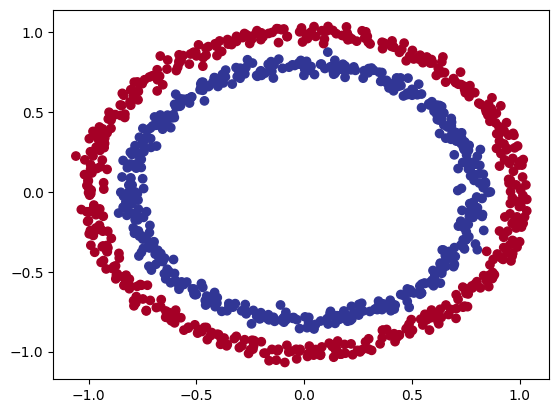

In [6]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0], 
            y=X[:, 1], 
            c=y, 
            cmap=plt.cm.RdYlBu)

In [7]:
import torch
import numpy as np 

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [8]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [9]:
import torch 
from torch import nn

In [10]:


device = "mps" if torch.mps.is_available() else "cpu"
print("Device being used is ", device)

Device being used is  mps


In [11]:
class CircleModule(nn.Module):
    def __init__(self) : 
        super().__init__()

        self.layer1 = nn.Linear(in_features= 2 , out_features=5)
        self.layer2 = nn.Linear(in_features=5 , out_features=1)

    def forward(self , X):
        return self.layer2(self.layer1(X))
    
model_0 = CircleModule().to(device)
model_0

CircleModule(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [12]:
loss = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_0.parameters() , lr=0.1)

In [13]:
def accuracy_fn(true_y , pred_y):
    correct = torch.eq(true_y , pred_y).sum().item()

    acc = (correct / len(pred_y)) * 100 

    return acc 

In [14]:
torch.manual_seed(seed=1000)

epochs = 1000 

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)


for epochs in range(epochs) : 
    #Training mode 


    model_0.train()

    #Forward pass and round values 

    y_logits = model_0(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))

    #Calculate loss 

    loss_val = loss(y_logits , y_train)
    acc = accuracy_fn(y_train , y_preds)

    #Zero grad optimizer 

    optimizer.zero_grad()

    #Backwards the loss 

    loss_val.backward()

    #Step the optimizer 

    optimizer.step()


    model_0.eval()

    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))

        test_loss = loss(test_preds , y_test) 

        test_acc = accuracy_fn(y_test , test_preds)

        # Print out what's happening every 10 epochs
    if epochs % 100 == 0:
        print(f"Epoch: {epochs} | Loss: {test_loss}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.6931471824645996, Accuracy: 50.00% | Test loss: 0.69315, Test acc: 50.00%
Epoch: 100 | Loss: 0.7601037621498108, Accuracy: 50.12% | Test loss: 0.76010, Test acc: 48.50%
Epoch: 200 | Loss: 0.7582043409347534, Accuracy: 50.25% | Test loss: 0.75820, Test acc: 49.00%
Epoch: 300 | Loss: 0.7649083733558655, Accuracy: 50.38% | Test loss: 0.76491, Test acc: 48.50%
Epoch: 400 | Loss: 0.768707275390625, Accuracy: 50.50% | Test loss: 0.76871, Test acc: 47.50%
Epoch: 500 | Loss: 0.7749084234237671, Accuracy: 51.25% | Test loss: 0.77491, Test acc: 46.50%
Epoch: 600 | Loss: 0.7799084186553955, Accuracy: 51.12% | Test loss: 0.77991, Test acc: 45.50%
Epoch: 700 | Loss: 0.7749083638191223, Accuracy: 51.12% | Test loss: 0.77491, Test acc: 46.50%
Epoch: 800 | Loss: 0.7792101502418518, Accuracy: 51.38% | Test loss: 0.77921, Test acc: 46.00%
Epoch: 900 | Loss: 0.7811095714569092, Accuracy: 51.12% | Test loss: 0.78111, Test acc: 45.50%


In [15]:
def plot_predictions(X_train=X_train , X_test= X_test ,
                      y_train = y_train , y_test = y_test ,
                        predictions = None ) : 
    
    X_test , X_train = X_test.to('cpu').numpy() ,  X_train.to('cpu').numpy()
    y_test , y_train = y_test.to('cpu').numpy() ,  y_train.to('cpu').numpy()

    plt.scatter(X_train[:,0] , X_train[:,1] ,c = y_train , s=4)

    plt.scatter(X_test[:,0] , X_test[:,1] ,c = y_test , s=4)

    if predictions is not None : 
        plt.scatter(X_test[:,0] , X_test[:,1] ,c = y_preds , s=4)



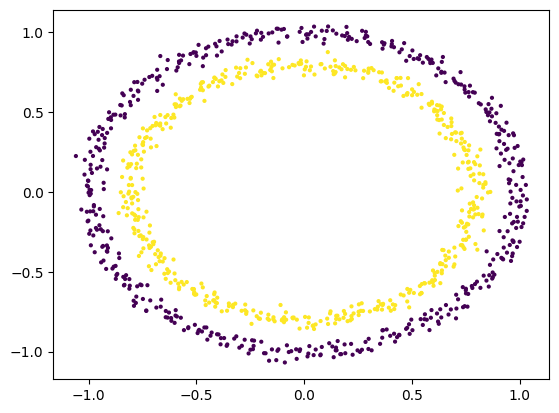

In [16]:
plot_predictions()




In [17]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [18]:
from helper_functions import plot_predictions, plot_decision_boundary

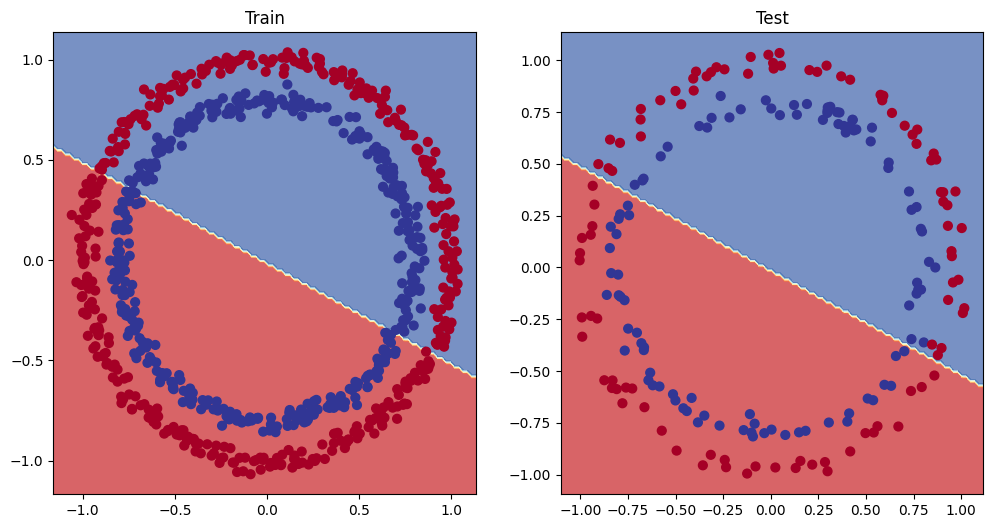

In [19]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [20]:
class CircleModule(nn.Module):
    def __init__(self) : 
        super().__init__()

        self.layer1 = nn.Linear(in_features= 2 , out_features=10)
        self.layer2 = nn.Linear(in_features=10 , out_features=10)
        self.layer3 = nn.Linear(in_features=10 , out_features= 1)
        self.relu = nn.ReLU()

    def forward(self , X):
        
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(X)))))
    
model_3 = CircleModule().to(device)
model_3

CircleModule(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [21]:
loss = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model_3.parameters() , lr = 0.01)

In [22]:
torch.manual_seed(seed=1000)

epochs = 500 

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)


for epochs in range(epochs) : 
    #Training mode 


    model_3.train()

    #Forward pass and round values 

    y_logits = model_3(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))

    #Calculate loss 

    loss_val = loss(y_logits , y_train)
    acc = accuracy_fn(y_train , y_preds)

    #Zero grad optimizer 

    optimizer.zero_grad()

    #Backwards the loss 

    loss_val.backward()

    #Step the optimizer 

    optimizer.step()


    model_3.eval()

    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))

        test_loss = loss(test_preds , y_test) 

        test_acc = accuracy_fn(y_test , test_preds)

        # Print out what's happening every 100  epochs
    if epochs % 100 == 0:
        print(f"Epoch: {epochs} | Loss: {test_loss}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.8132616281509399, Accuracy: 50.00% | Test loss: 0.81326, Test acc: 50.00%
Epoch: 100 | Loss: 0.583316445350647, Accuracy: 90.12% | Test loss: 0.58332, Test acc: 86.50%
Epoch: 200 | Loss: 0.5063049793243408, Accuracy: 99.88% | Test loss: 0.50630, Test acc: 99.50%
Epoch: 300 | Loss: 0.5032044053077698, Accuracy: 100.00% | Test loss: 0.50320, Test acc: 100.00%
Epoch: 400 | Loss: 0.5032044053077698, Accuracy: 100.00% | Test loss: 0.50320, Test acc: 100.00%


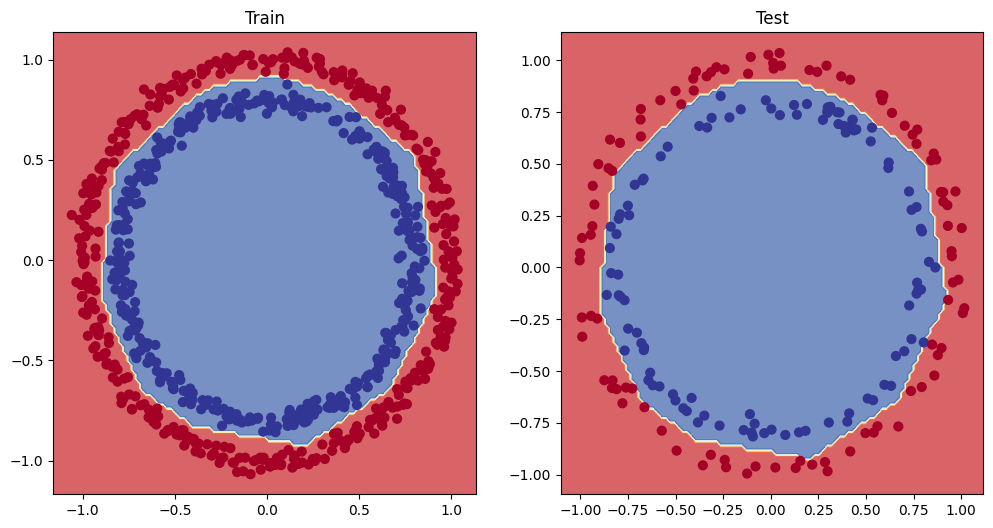

In [23]:
# Plot decision boundaries for model_3
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

In [24]:
# Let's compare: SGD with higher learning rate
class CircleModule(nn.Module):
    def __init__(self) : 
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=10)
        self.layer2 = nn.Linear(in_features=10, out_features=10)
        self.layer3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, X):
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(X)))))

model_sgd = CircleModule().to(device)

# SGD with HIGHER learning rate (key difference!)
loss_fn = nn.BCEWithLogitsLoss()
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.5)  # Higher LR!

torch.manual_seed(42)
epochs = 1500

for epoch in range(epochs):
    model_sgd.train()
    y_logits = model_sgd(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))
    
    loss_val = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_preds)
    
    optimizer_sgd.zero_grad()
    loss_val.backward()
    optimizer_sgd.step()
    
    if epoch % 100 == 0:
        model_sgd.eval()
        with torch.inference_mode():
            test_logits = model_sgd(X_test).squeeze()
            test_preds = torch.round(torch.sigmoid(test_logits))
            test_acc = accuracy_fn(y_test, test_preds)
        print(f"Epoch: {epoch} | Train Acc: {acc:.2f}% | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Train Acc: 50.00% | Test Acc: 50.00%
Epoch: 100 | Train Acc: 51.75% | Test Acc: 48.00%
Epoch: 200 | Train Acc: 52.75% | Test Acc: 48.00%
Epoch: 300 | Train Acc: 55.25% | Test Acc: 49.50%
Epoch: 400 | Train Acc: 65.50% | Test Acc: 60.00%
Epoch: 500 | Train Acc: 57.12% | Test Acc: 58.50%
Epoch: 600 | Train Acc: 68.62% | Test Acc: 62.50%
Epoch: 700 | Train Acc: 96.12% | Test Acc: 77.00%
Epoch: 800 | Train Acc: 97.00% | Test Acc: 79.50%
Epoch: 900 | Train Acc: 88.75% | Test Acc: 98.50%
Epoch: 1000 | Train Acc: 89.25% | Test Acc: 93.00%
Epoch: 1100 | Train Acc: 90.00% | Test Acc: 88.50%
Epoch: 1200 | Train Acc: 93.50% | Test Acc: 94.50%
Epoch: 1300 | Train Acc: 54.12% | Test Acc: 50.00%
Epoch: 1400 | Train Acc: 99.88% | Test Acc: 98.50%


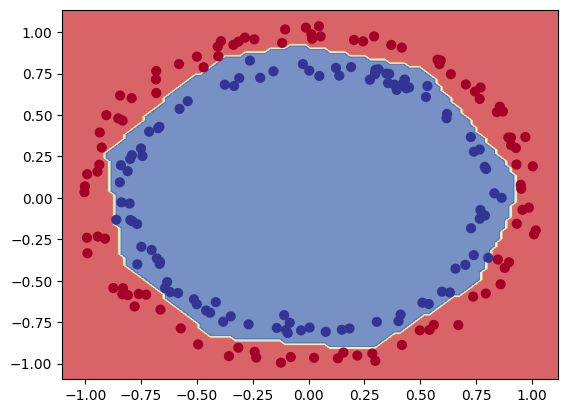

In [25]:
plot_decision_boundary(model_sgd , X_test , y_test)

In [26]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


In [27]:
NUM_CENTERS = 6
NUM_FEATURES = 2 

X_blobs , y_blobs = make_blobs(n_samples=1000 ,
                            centers= NUM_CENTERS,
                           n_features= NUM_FEATURES,
                              random_state=900)

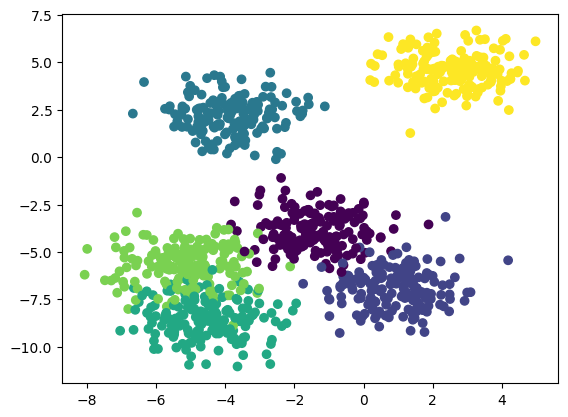

In [28]:
plt.scatter(X_blobs[:,0], X_blobs[: , 1] , c= y_blobs)

In [29]:
y_train , y_test = train_test_split(y_blobs , test_size=0.2 , random_state=1000)
X_train , X_val = train_test_split(X_blobs , test_size=0.2 , random_state=1000)

In [30]:
X_train = torch.from_numpy(X_train).type(torch.float32)
X_val = torch.from_numpy(X_val).type(torch.float32)
y_train = torch.from_numpy(y_train).type(torch.float32)
y_test = torch.from_numpy(y_test).type(torch.float32)

In [31]:
X_train

tensor([[-4.7665,  2.5649],
        [-5.2482,  1.5924],
        [-3.0869,  2.9188],
        ...,
        [ 1.1072, -6.1989],
        [-3.8529,  2.2296],
        [-4.6872, -8.8160]])

In [32]:
device = 'mps' if torch.mps.is_available() else 'cpu'
device 

'mps'

In [33]:
from torch import nn 
class BlobClassifier(nn.Module) :
    def __init__(self , input_features , output_features , hidden_layers = 8 ):

        super().__init__()
        self.sequential = nn.Sequential(
            nn.Linear(in_features= input_features , out_features=hidden_layers),
            nn.ReLU(),
            nn.Linear(in_features=hidden_layers , out_features=hidden_layers),
            nn.ReLU(),
            nn.Linear(in_features=hidden_layers , out_features= output_features))
    
    def forward(self , X) : 
        return self.sequential(X)
    

model_4 = BlobClassifier(input_features= NUM_FEATURES ,
                          output_features=NUM_CENTERS ,
                            hidden_layers=8).to(device)




In [34]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params= model_4.parameters())

In [41]:
torch.manual_seed(seed=1000)

epochs = 1500 

X_blob_train, y_blob_train = X_train.to(device), y_train.to(device)
X_blob_test, y_blob_test = X_val.to(device), y_test.to(device)

for epochs in range(epochs+1):

    model_4.train()

    y_logits = model_4(X_blob_train)
    y_preds = torch.softmax(y_logits , dim= 1).argmax(dim=1)

    loss = loss_fn(y_logits , y_blob_train)
    acc = accuracy_fn(y_blob_train , y_preds )


    optimizer.zero_grad()


    loss.backward()


    optimizer.step()

    model_4.eval()

    with torch.inference_mode() :

        test_logits = model_4(X_blob_test)
        test_preds = torch.softmax(test_logits , dim=1).argmax(dim=1)

        test_loss = loss_fn(test_logits ,y_blob_test )
        acc = accuracy_fn(y_blob_test , test_preds)

    if epochs % 100 == 0:
            print(f"Epoch: {epochs} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.09584, Acc: 96.50% | Test Loss: 0.06656, Test Acc: 98.50%
Epoch: 100 | Loss: 0.09576, Acc: 96.50% | Test Loss: 0.06656, Test Acc: 98.50%
Epoch: 200 | Loss: 0.09567, Acc: 96.50% | Test Loss: 0.06660, Test Acc: 98.50%
Epoch: 300 | Loss: 0.09560, Acc: 96.50% | Test Loss: 0.06661, Test Acc: 98.50%
Epoch: 400 | Loss: 0.09552, Acc: 96.50% | Test Loss: 0.06668, Test Acc: 98.50%
Epoch: 500 | Loss: 0.09545, Acc: 96.50% | Test Loss: 0.06673, Test Acc: 98.50%
Epoch: 600 | Loss: 0.09537, Acc: 96.50% | Test Loss: 0.06680, Test Acc: 98.50%
Epoch: 700 | Loss: 0.09530, Acc: 96.50% | Test Loss: 0.06688, Test Acc: 98.50%
Epoch: 800 | Loss: 0.09522, Acc: 96.50% | Test Loss: 0.06697, Test Acc: 98.50%
Epoch: 900 | Loss: 0.09514, Acc: 96.50% | Test Loss: 0.06712, Test Acc: 98.50%
Epoch: 1000 | Loss: 0.09506, Acc: 96.00% | Test Loss: 0.06729, Test Acc: 98.50%
Epoch: 1100 | Loss: 0.09499, Acc: 96.00% | Test Loss: 0.06743, Test Acc: 98.50%
Epoch: 1200 | Loss: 0.09492, Acc: 96.00% | Test Loss

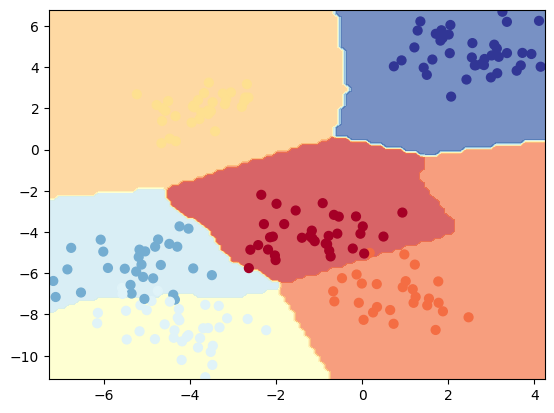

In [42]:
plot_decision_boundary(model_4 , X_blob_test , y_blob_test)